In [10]:
import os
import sys
import re
import tqdm
from pathlib import Path
from dotenv import load_dotenv
import supervision as sv
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

load_dotenv('.env')
DIR_SRC = os.getenv('DIR_SRC')
dir_s1 = Path("out") / "study1"
ls_meta = [f for f in dir_s1.iterdir() if f.suffix == '.csv' and f.name.startswith('results_')]
ls_meta

[PosixPath('out/study1/results_3.csv'),
 PosixPath('out/study1/results_1.csv'),
 PosixPath('out/study1/results_0.csv'),
 PosixPath('out/study1/results_2.csv'),
 PosixPath('out/study1/results_4.csv')]

In [18]:
data = pd.read_csv(ls_meta[0])
for i in range(1, len(ls_meta)):
    data_tmp = pd.read_csv(ls_meta[i])
    data = pd.concat([data, data_tmp])
data_sub = data.query("model == 'yolo11n'")
data_sub
# study1: n (5) x split (6) x rep (20) = 600
# study2: model (5) x split (6) = 30
# total: 630

,model,n_params,n_samples,thread,iters,split,strategy,time_passed,map5095,map50,precision,recall,f1,n_all,n_fn,n_fp
36,yolo11n,2.6,64,3,1,test_a01,baseline,8.72,0.3351,0.8833,0.8823,0.8772,0.8797,1734,213,203
37,yolo11n,2.6,64,3,1,test_a01,bo_exploration,669.23,0.2521,0.7512,0.1072,0.8766,0.1910,1734,214,12659
38,yolo11n,2.6,64,3,1,test_a01,bo_exploitation,206.90,0.2830,0.8058,0.3370,0.8749,0.4866,1734,217,2984
39,yolo11n,2.6,64,3,1,test_a01,grid_search,639.46,0.2526,0.7540,0.1067,0.8749,0.1902,1734,217,12700
40,yolo11n,2.6,64,3,1,test_a02,baseline,6.29,0.2646,0.7649,0.7722,0.7954,0.7837,1266,259,297
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43,yolo11n,2.6,64,4,1,test_a02,grid_search,555.35,0.1633,0.5787,0.1685,0.7709,0.2766,1266,290,4815
44,yolo11n,2.6,64,4,1,test_a03,baseline,1.25,0.2550,0.6904,0.8313,0.6053,0.7005,342,135,42
45,yolo11n,2.6,64,4,1,test_a03,bo_exploration,151.17,0.1748,0.5089,0.3377,0.6053,0.4335,342,135,406
46,yolo11n,2.6,64,4,1,test_a03,bo_exploitation,44.93,0.1939,0.5525,0.4641,0.6053,0.5254,342,135,239


In [19]:
# calculate mean, median, std, min, max
data_sum = data_sub.groupby(['n_samples', 'split', "strategy"]).agg(
    pre_mean=pd.NamedAgg(column='precision', aggfunc='mean'),
    pre_median=pd.NamedAgg(column='precision', aggfunc='median'),
    pre_std=pd.NamedAgg(column='precision', aggfunc='std'),
    pre_min=pd.NamedAgg(column='precision', aggfunc='min'),
    pre_max=pd.NamedAgg(column='precision', aggfunc='max'),
    rec_mean=pd.NamedAgg(column='recall', aggfunc='mean'),
    rec_median=pd.NamedAgg(column='recall', aggfunc='median'),
    rec_std=pd.NamedAgg(column='recall', aggfunc='std'),
    rec_min=pd.NamedAgg(column='recall', aggfunc='min'),
    rec_max=pd.NamedAgg(column='recall', aggfunc='max'),
).reset_index()

In [20]:
data_sum.to_csv(Path("out") / "study1_pivot.csv", index=False)

In [29]:
data_fig = data_sub.melt(id_vars=["n_samples", "split", "strategy"], var_name="metric", value_name="score")
data_fig = data_fig.query("metric in ['precision', 'recall']")
data_fig

,n_samples,split,strategy,metric,score
595,64,test_a01,baseline,precision,0.8823
596,64,test_a01,bo_exploration,precision,0.1072
597,64,test_a01,bo_exploitation,precision,0.337
598,64,test_a01,grid_search,precision,0.1067
599,64,test_a02,baseline,precision,0.7722
...,...,...,...,...,...
760,64,test_a02,grid_search,recall,0.7709
761,64,test_a03,baseline,recall,0.6053
762,64,test_a03,bo_exploration,recall,0.6053
763,64,test_a03,bo_exploitation,recall,0.6053


## Study 1

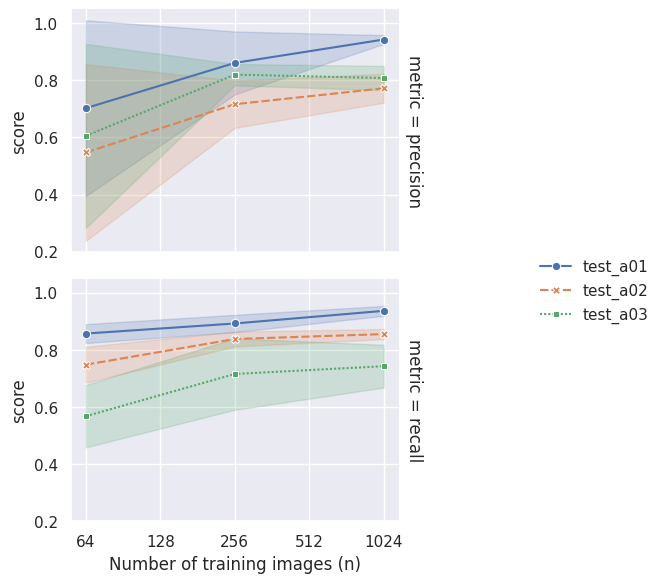

In [31]:
sns.set("notebook")
splits_s1 = ["test_a01", "test_a02", "test_a03"]
g = sns.FacetGrid(
    data_fig,
    row="metric",
    # col_wrap=2,
    margin_titles=True,
    sharey=True,
)
g.map_dataframe(sns.lineplot, 
    x="n_samples", y="score", 
    hue="split", style="split",
    hue_order=splits_s1,
    style_order=splits_s1,
    err_style="band", errorbar=("sd", 1),
    markers=True,
    # palette=["Grey", "#FF1F5B", "#00B000", "#009ADE", "#AF58BA"],
    )
# title
# g.figure.suptitle("Model Generalization in each Data Configuration")
g.set(
    xscale="log",
    xticks=[2**i for i in range(6, 11)],
    xticklabels=[2**i for i in range(6, 11)],
    xlabel="Number of training images (n)",)
g.figure.subplots_adjust(right=1.2)
g.add_legend()
g.figure.set_size_inches(8, 6)
g.savefig(Path("out") / "results_study1.png", dpi=300)


## Study 2

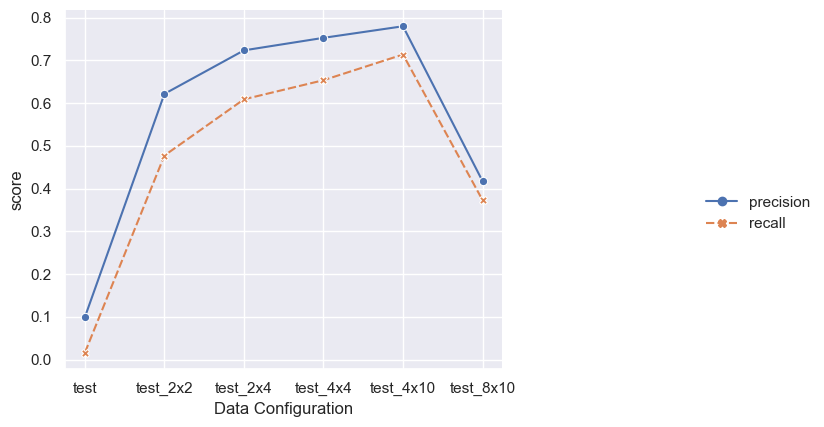

In [8]:
data_s2 = data_fig.\
        query("study == 2").\
        query("metric in ['precision', 'recall']").\
            query("model == 'yolov8n'")
# lineplot
# x: split (test, test_2x2, test_2x4, test_4x4, test_4x10, test_8x10)
# y: score
# hue: model
# style: model
# facet_grid: metric
sns.set("notebook")
g = sns.FacetGrid(
    data_s2,
    margin_titles=True,
    sharey=False,
)
g.map_dataframe(sns.lineplot,
    x="split", y="score",
    hue="metric", style="metric",
    err_style="band", errorbar=("se", 2),
    markers=True,
    # palette=["Grey", "#FF1F5B", "#00B000", "#009ADE", "#AF58BA"],
    )
# title
g.set(xlabel="Data Configuration",)

g.add_legend()
g.figure.set_size_inches(10, 5)
# dpi
g.savefig(os.path.join(DIR_SRC, "out", "conf25", "results_study2_conf25.png"), dpi=300)
